# Metabolite cell-cell communication in a tumour microenvironment

The companion tutorial scored metabolism *within* each cell. Here we
ask the question that needs the whole ecosystem: in a head & neck
tumour, which cell types **feed which** — which metabolites flow from
which sender to which receiver? `ov.single.MetaboliteCCC` wraps
MEBOCOST to infer metabolite-mediated cell-cell communication, and
reuses the `ov.pl.ccc_*` communication plots.

## Part.1 The idea behind MEBOCOST

A metabolite-mediated communication event has two ends:

- a **sender** cell type that makes a metabolite available — read out
  as high expression of its synthesising / exporting enzymes;
- a **receiver** cell type that takes it up or senses it — high
  expression of a matching **sensor**: a transporter, a cell-surface
  receptor or a nuclear receptor.

MEBOCOST estimates per-cell-type metabolite abundance from enzyme
expression, pairs metabolites with sensors through a curated
database, and scores every sender to receiver event against a
permutation null. Tumour metabolism is not cell-autonomous — malignant
cells, fibroblasts and immune cells feed and starve one another, and
this is how that traffic is mapped.

In [1]:
import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Part.2 The HNSC tumour atlas

The same Puram et al. 2017 head & neck cancer atlas (GSE103322) used
by the per-cell metabolism tutorial — 5,578 cells, malignant plus the
stromal and immune microenvironment.

In [2]:
adata = ov.datasets.metabolism_hnsc()
adata.obs['celltype'].value_counts()

🔍 Downloading data to ./data/hnsc_puram2017_full.h5ad
⚠️ File ./data/hnsc_puram2017_full.h5ad already exists


celltype
Malignant      2215
Fibroblast     1440
T cell         1237
Endothelial     260
B cell          138
Mast            120
Macrophage       98
Dendritic        51
myocyte          19
Name: count, dtype: int64

## Part.3 Infer metabolite communication

`ov.single.MetaboliteCCC` takes the cell-type column as the unit of
communication. `run()` estimates metabolite abundance, pairs
metabolites with sensors and runs the permutation test.
`min_cell_number` drops cell types too small to estimate from, and
`n_shuffle` sizes the null (1000 for a publication; 100 here to keep
the tutorial quick).

In [3]:
mccc = ov.single.MetaboliteCCC(adata, group_key='celltype')
mccc.run(n_shuffle=100, min_cell_number=30, verbose=False)

In [4]:
# the strongest metabolite -> sensor communication events
mccc.result.nlargest(10, 'Commu_Score')[
    ['Sender', 'Receiver', 'Metabolite_Name', 'Sensor',
     'Commu_Score', 'permutation_test_fdr']]

,Sender,Receiver,Metabolite_Name,Sensor,Commu_Score,permutation_test_fdr
73,Mast,Malignant,L-Glutamine,SLC3A2,20.723214,0.0
37,Macrophage,Malignant,L-Glutamine,SLC3A2,19.115429,0.0
76,Mast,Macrophage,L-Glutamine,SLC3A2,14.312806,0.0
74,Mast,B cell,L-Glutamine,SLC3A2,14.117096,0.0
72,Mast,Fibroblast,L-Glutamine,SLC38A2,13.493294,0.0
40,Macrophage,Macrophage,L-Glutamine,SLC3A2,13.202364,0.0
74,Mast,B cell,L-Glutamine,SLC38A2,13.141793,0.0
38,Macrophage,B cell,L-Glutamine,SLC3A2,13.021839,0.0
10,Malignant,Malignant,L-Glutamine,SLC3A2,12.874932,0.0
52,Endothelial,Dendritic,Farnesyl pyrophosphate,GPR183,12.629885,0.0


## Part.4 The communication network

`to_comm_adata()` converts the MEBOCOST result into a communication
AnnData — the schema the `ov.pl.ccc_*` plots consume. The heatmap
sums communication strength over every sender to receiver pair; a
bright row is a metabolite *source*, a bright column a *sink*.

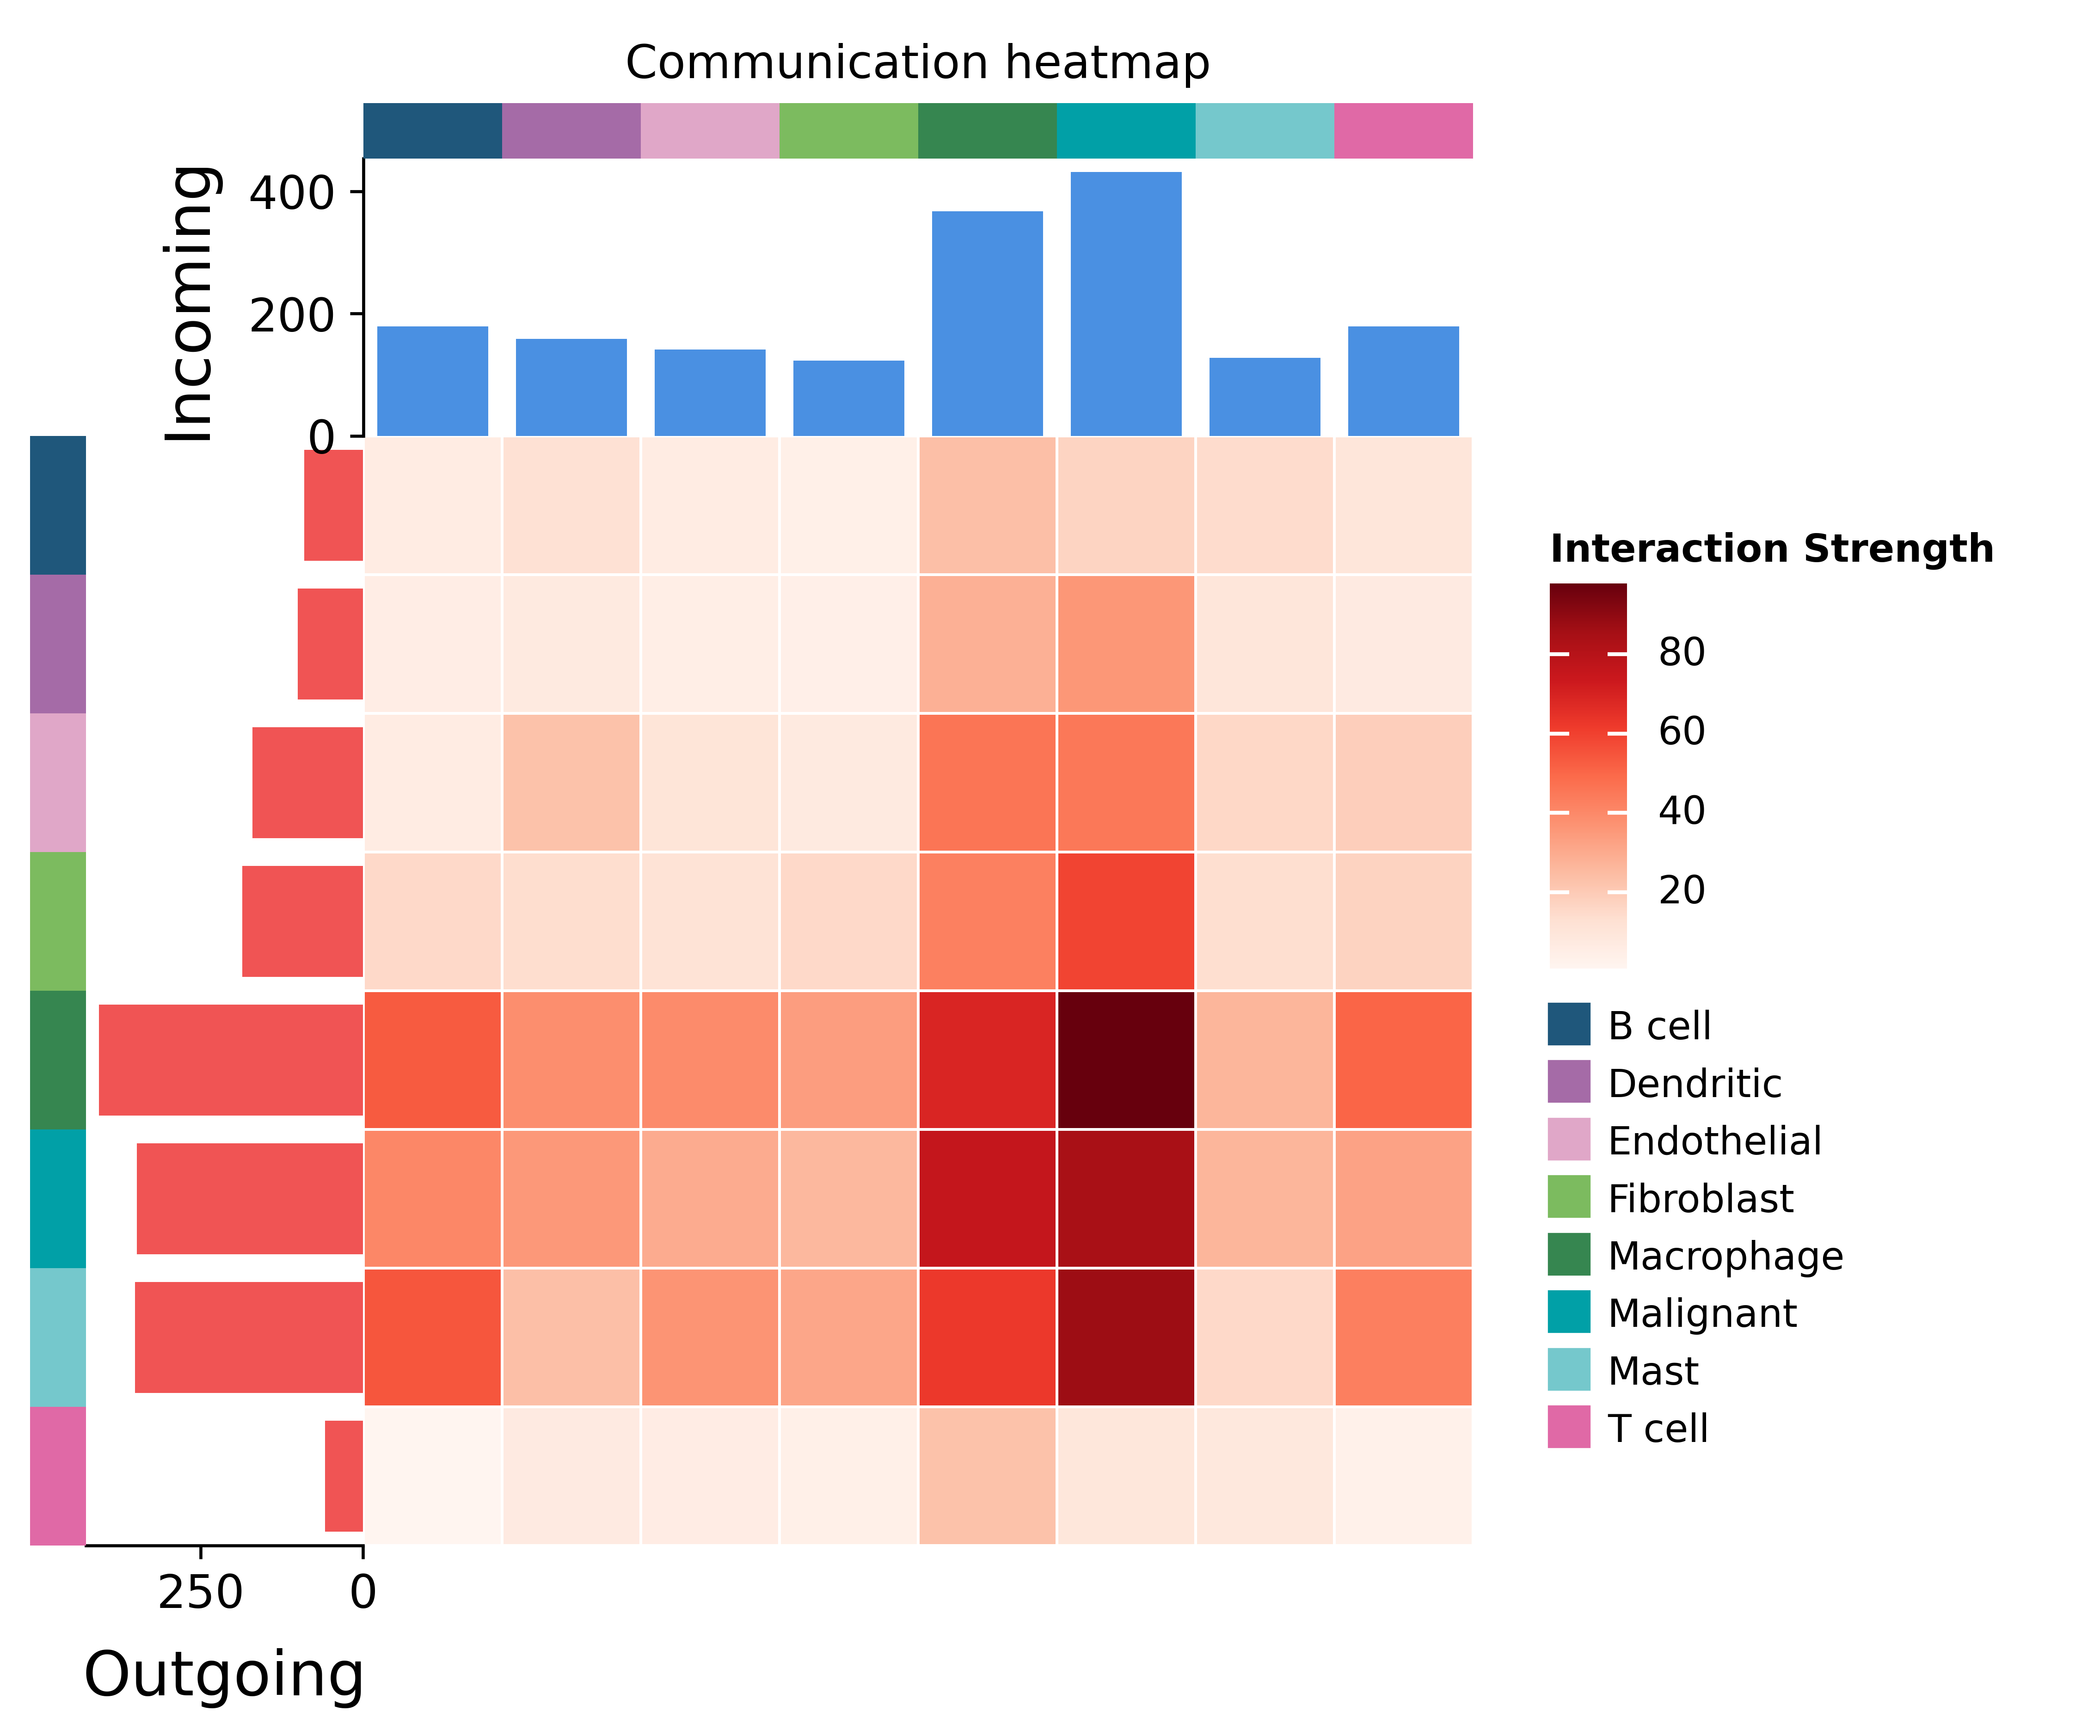

In [5]:
comm = mccc.to_comm_adata()
fig, ax = ov.pl.ccc_heatmap(comm, plot_type='heatmap')
fig

The same traffic as a directed network — arrows run from metabolite
senders to receivers, weighted by communication strength.

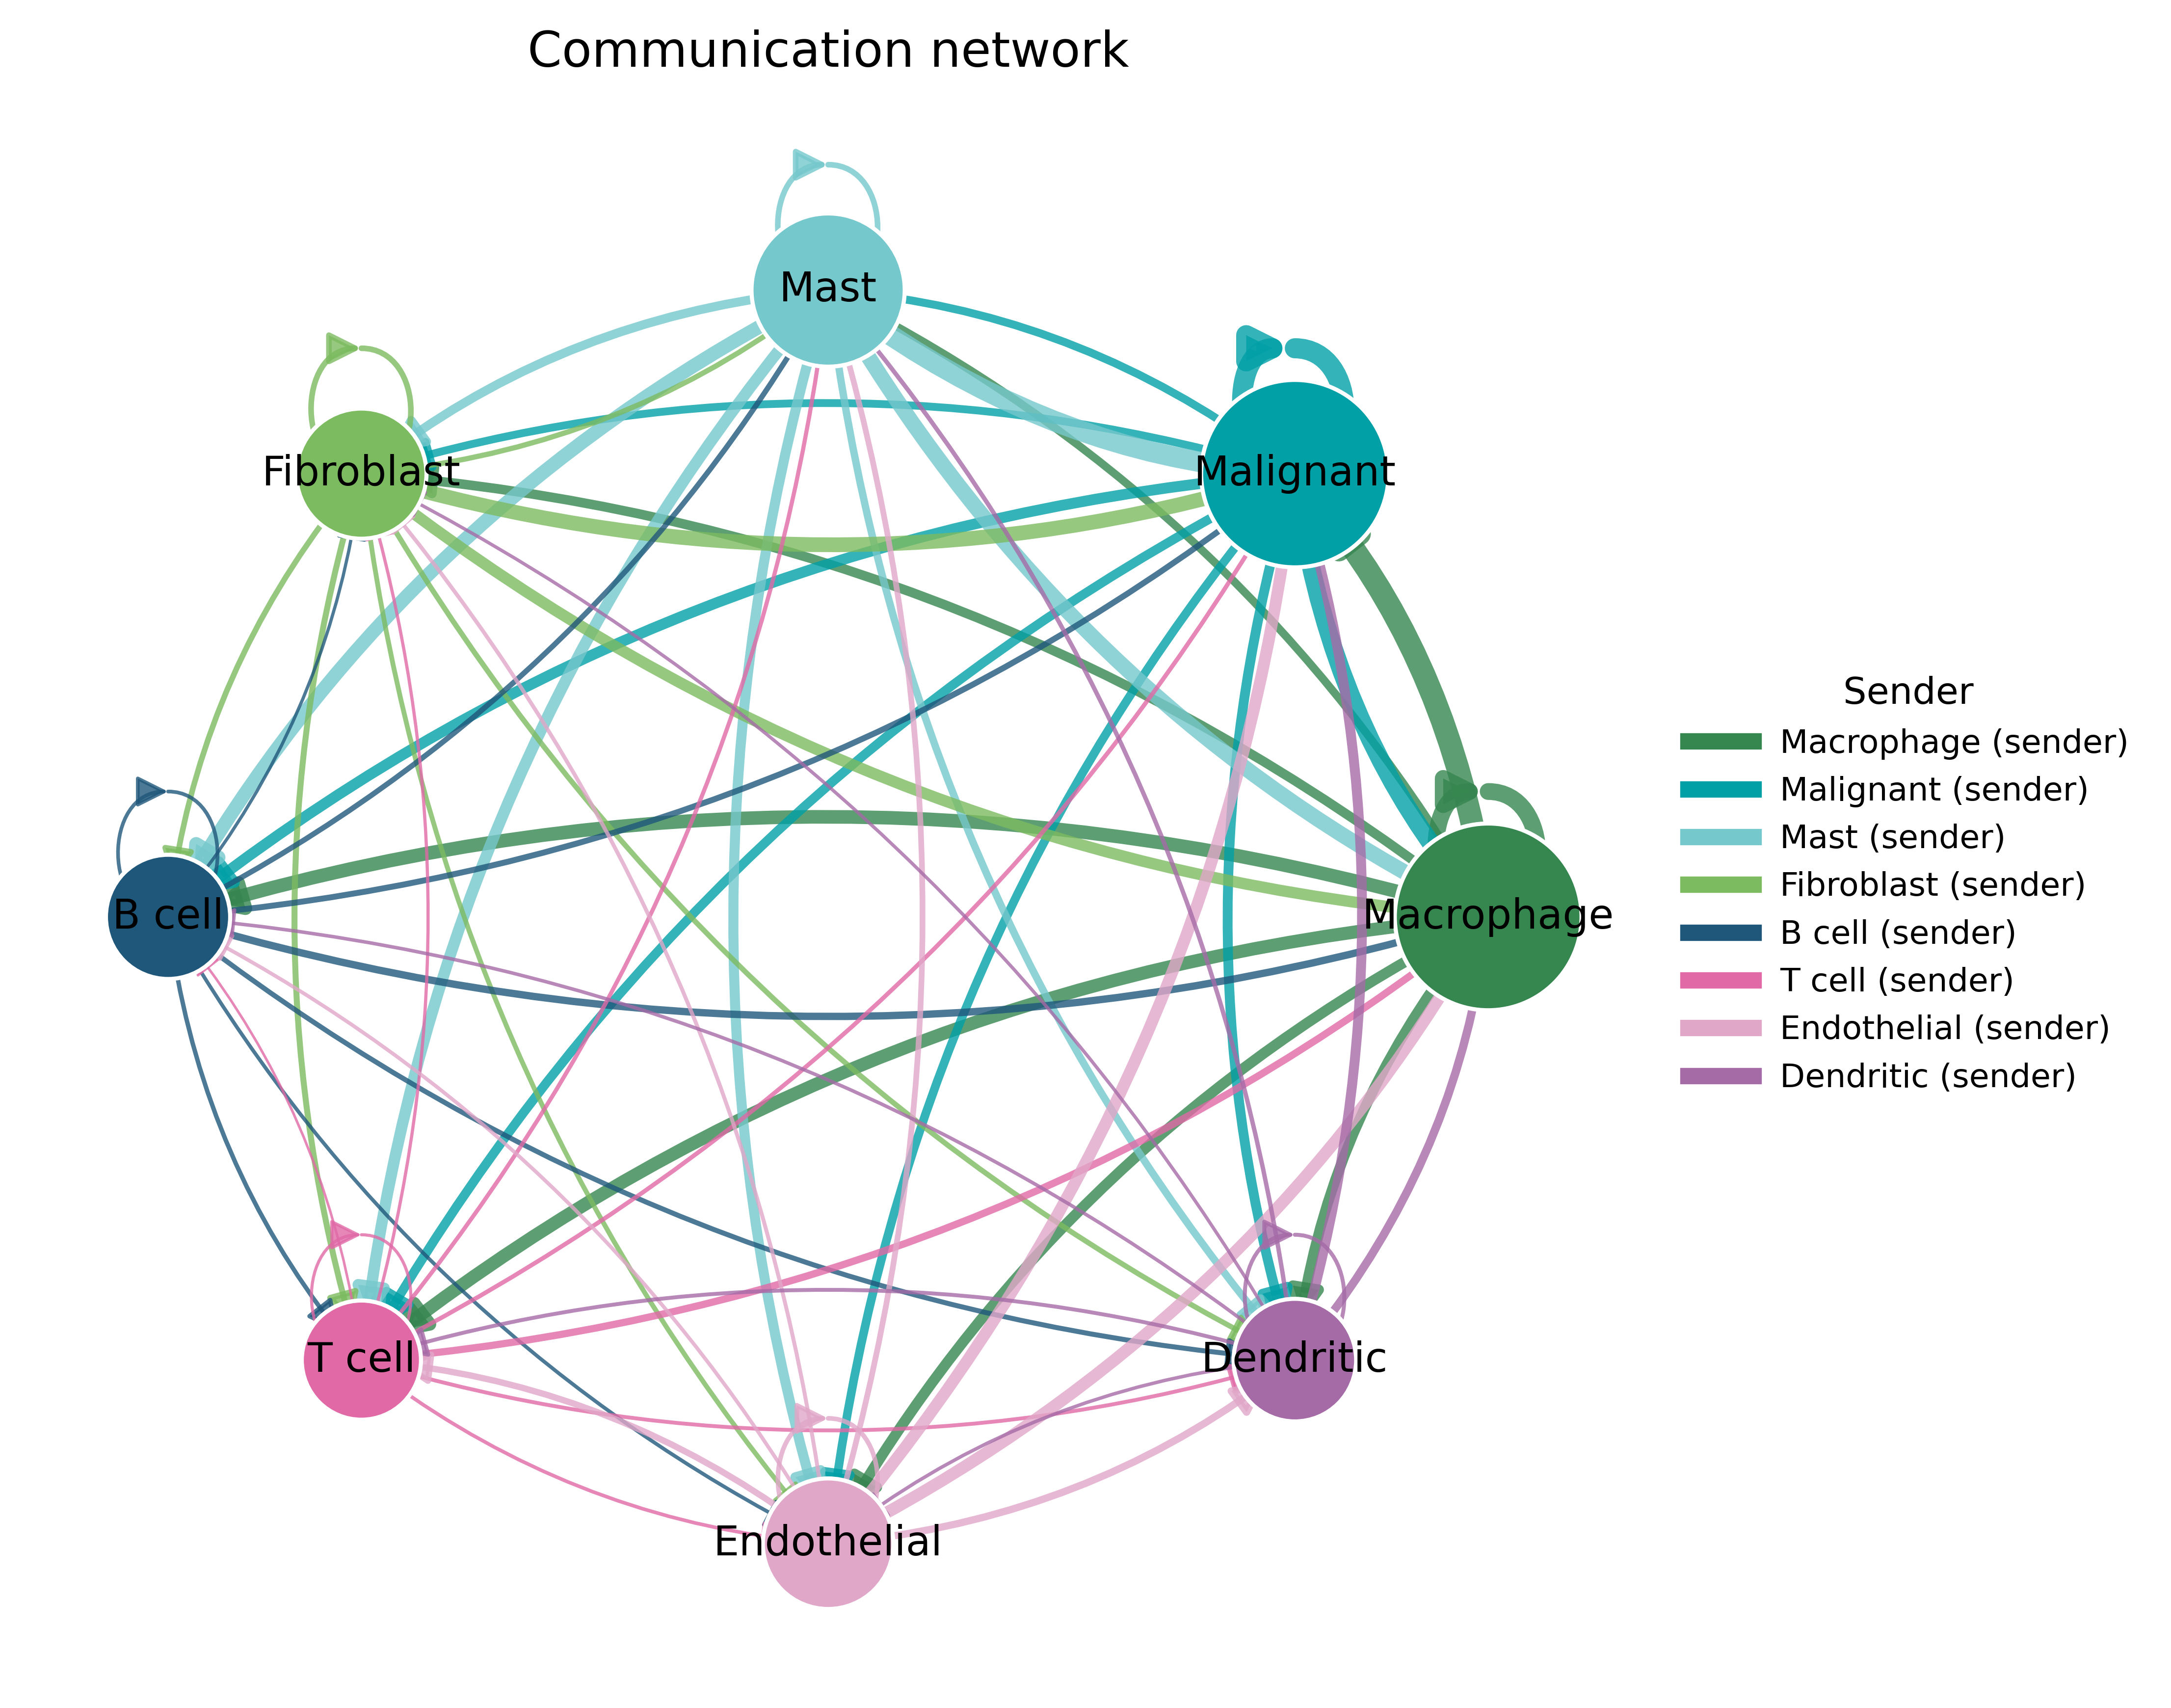

In [6]:
fig, ax = ov.pl.ccc_network_plot(comm, plot_type='circle')
fig

## Part.5 The dominant metabolite channels

A Sankey view follows the flow end to end — which cell types pour
the most metabolite signal into which receivers.

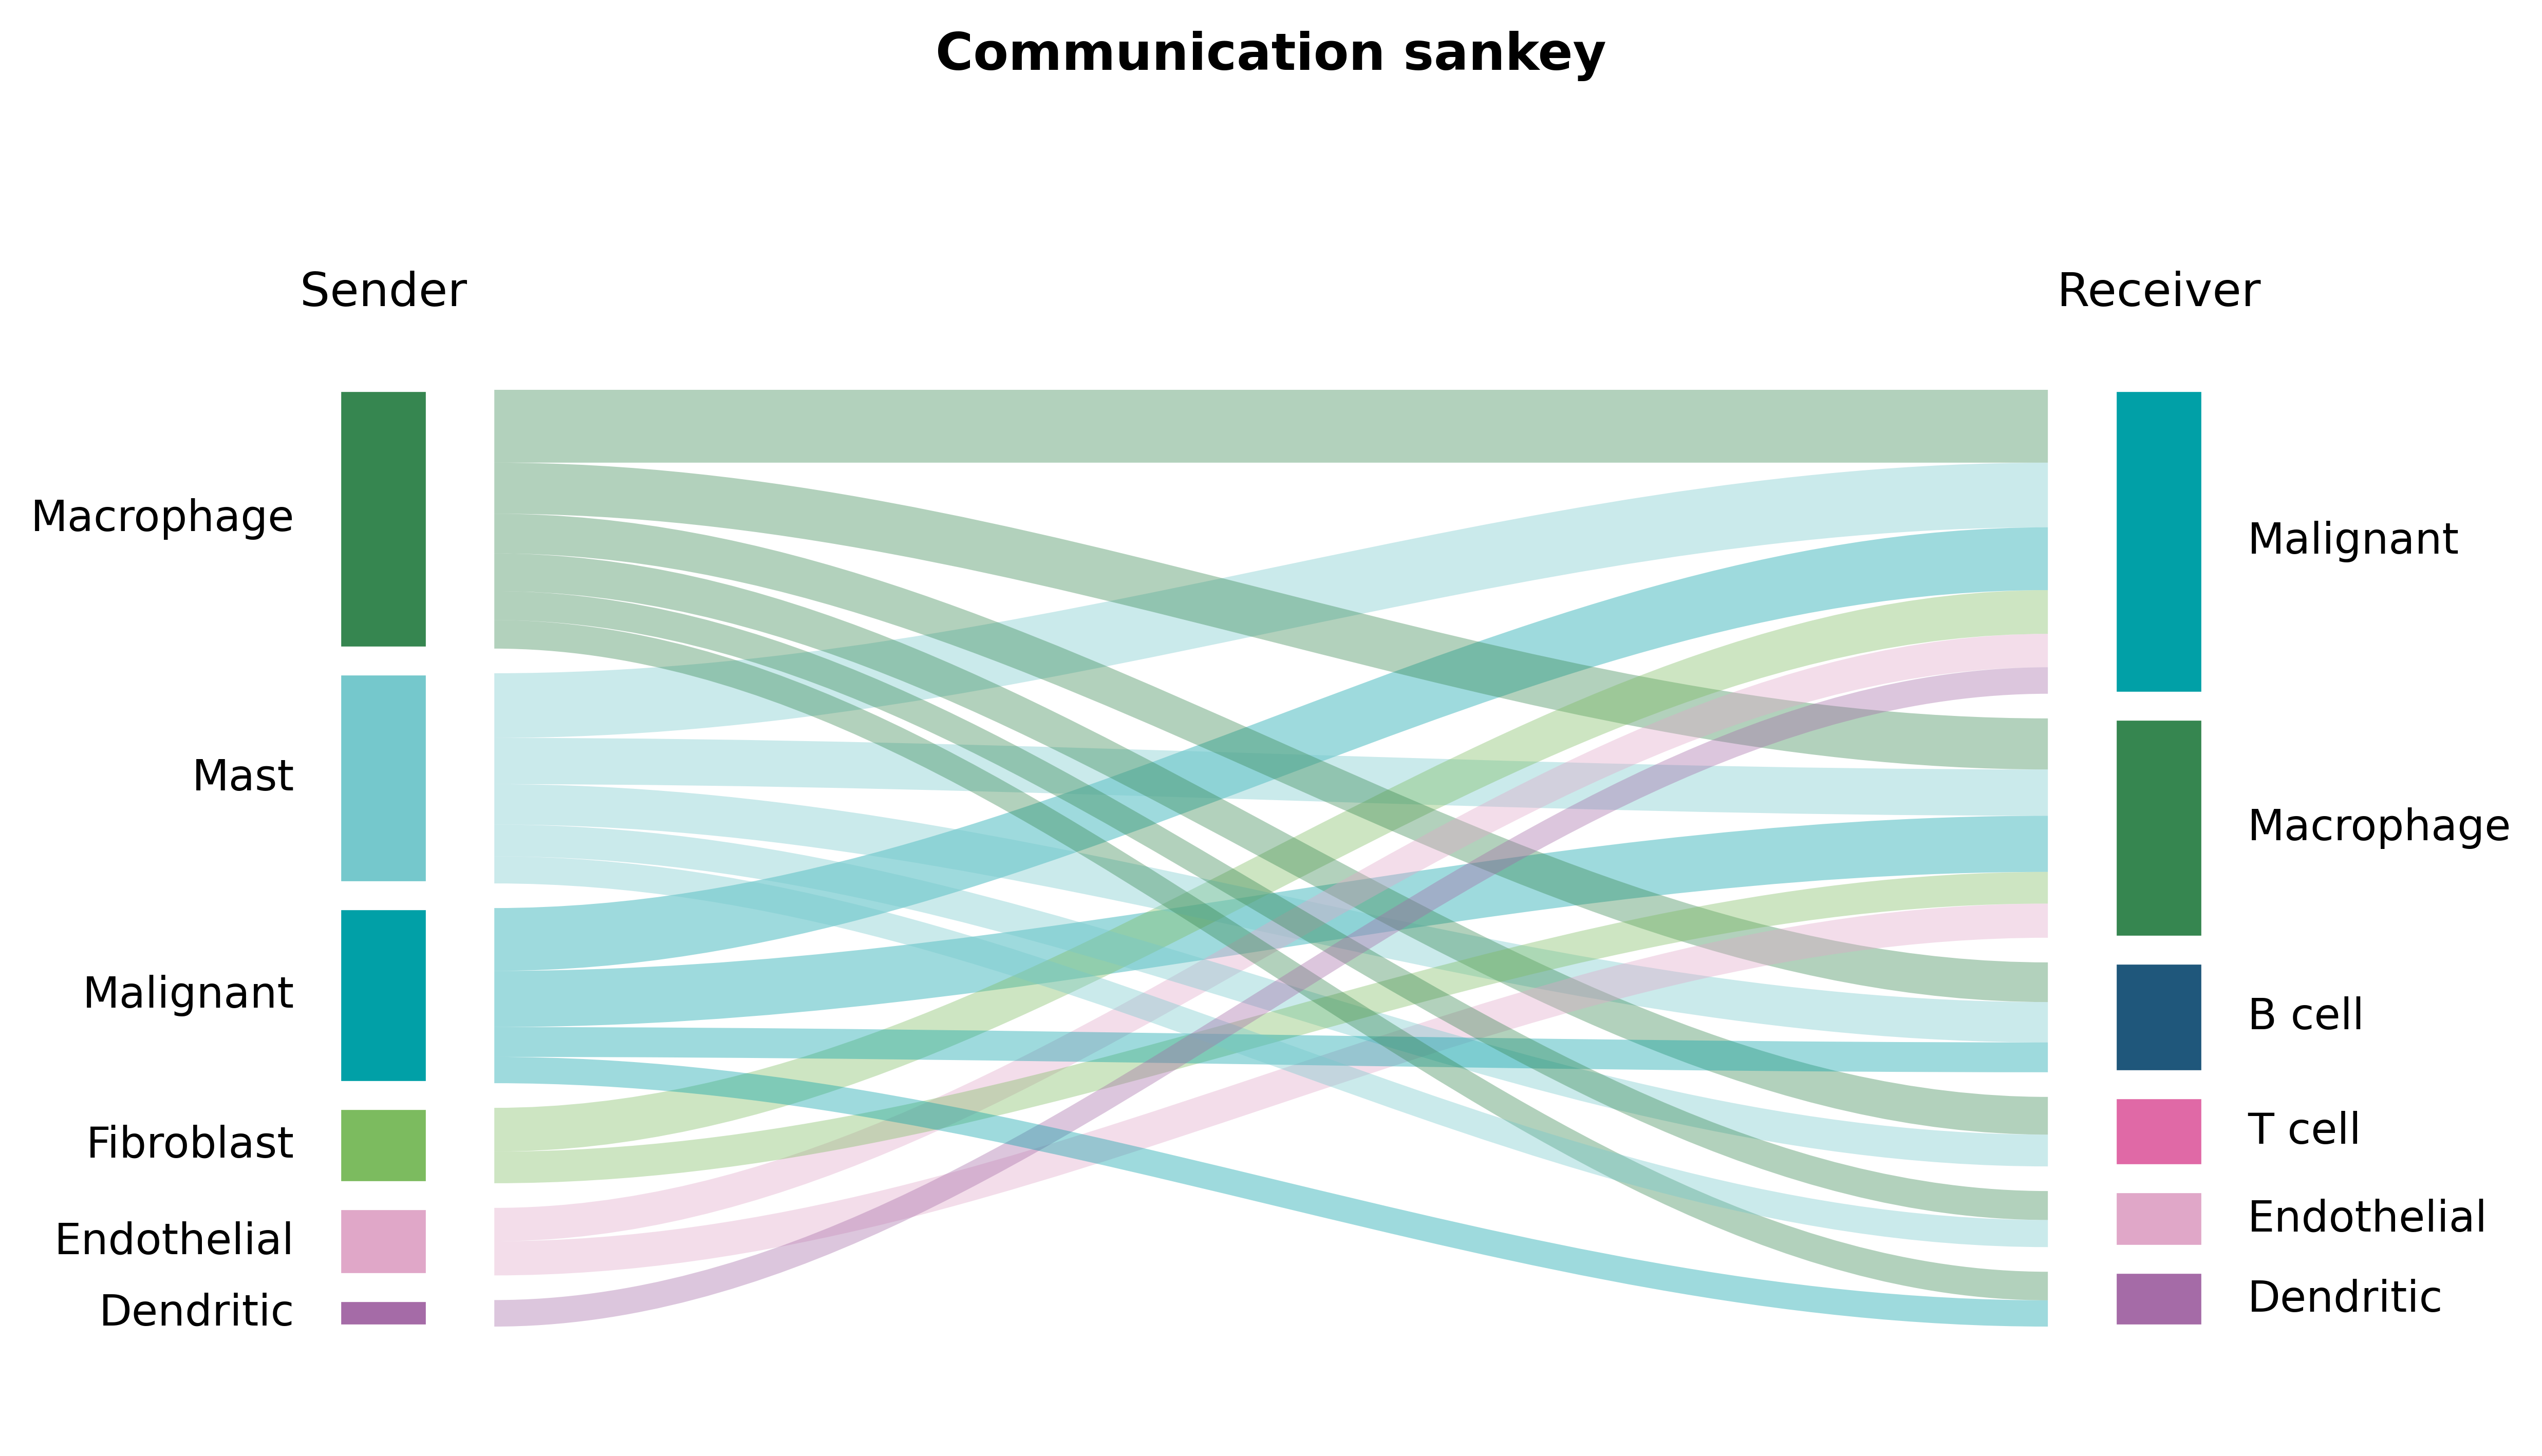

In [7]:
fig, ax = ov.pl.ccc_stat_plot(comm, plot_type='sankey')
fig

## Part.6 Malignant cells are a glutamine sink

Read the top events again: they nearly all converge on one channel —
malignant cells **receiving L-glutamine**. The sensors are SLC3A2
(CD98hc) and SLC38A2 — amino-acid **transporters**, not receptors —
so MEBOCOST is reading metabolite *uptake*. This is textbook cancer
biology: tumour cells are "glutamine-addicted", and the analysis
names who pays for the habit. The metabolites the malignant
compartment imports most:

In [8]:
recv = mccc.result[mccc.result['Receiver'] == 'Malignant']
(recv.groupby('Metabolite_Name')['Commu_Score'].sum()
     .sort_values(ascending=False).head(10))

Metabolite_Name
L-Glutamine                246.935687
Iron                        53.167821
Leukotriene B4              12.561020
gamma-Aminobutyric acid      9.449661
L-Serine                     8.482404
3-Hydroxybutyric acid        7.552795
Adenine                      7.424385
D-Mannose                    7.241953
Desmosterol                  6.615091
Cholesterol                  6.119173
Name: Commu_Score, dtype: float64

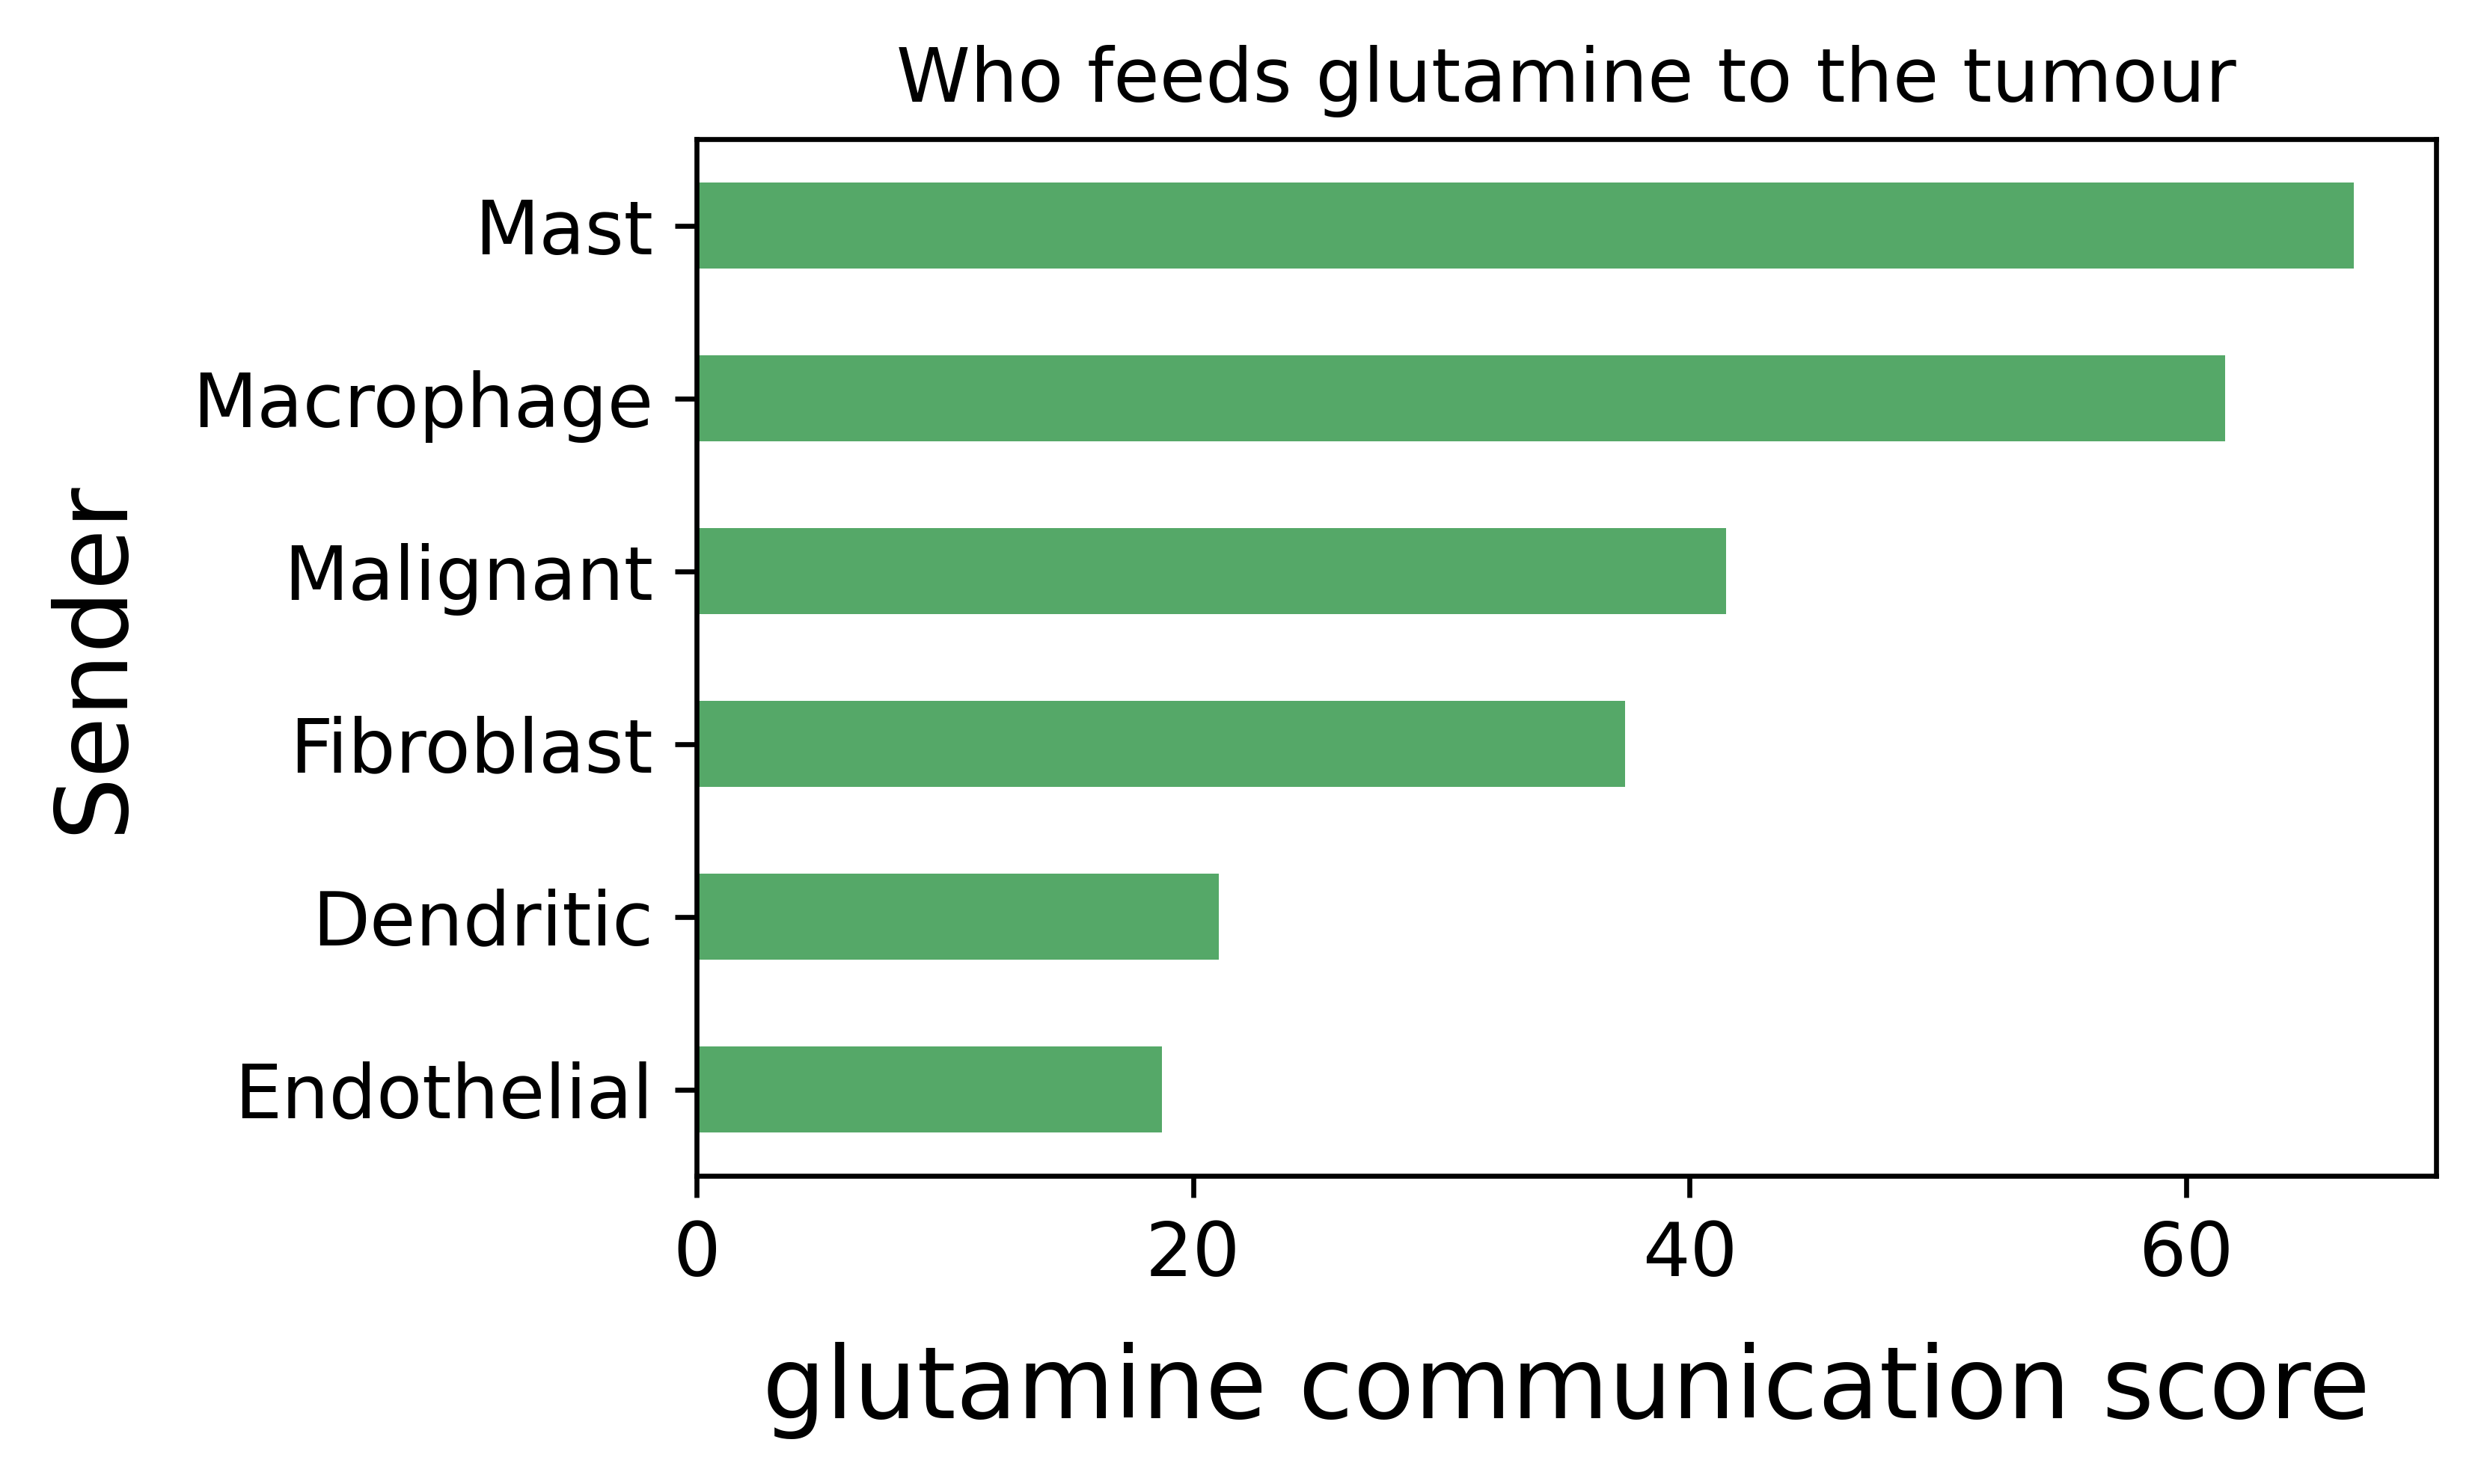

In [9]:
import matplotlib.pyplot as plt
plt.close('all')   # clear figures left open by the ccc_* plots
gln = mccc.result.query("Receiver == 'Malignant' "
                        "and Metabolite_Name == 'L-Glutamine'")
supply = gln.groupby('Sender')['Commu_Score'].sum().sort_values()
supply.plot.barh(color='#55A868', figsize=(5, 3),
                 xlabel='glutamine communication score',
                 title='Who feeds glutamine to the tumour')
plt.show()

---

## Recap

`ov.single.MetaboliteCCC` lifts the metabolism analysis from the
single cell to the metabolic *ecology* of the tumour. On this head &
neck cancer atlas it recovers a real dependency: the malignant
compartment is a **metabolite sink**, and mast cells and macrophages
are the chief suppliers of the L-glutamine that glutamine-addicted
tumour cells consume. It names the metabolite to sensor channels,
scores them against a permutation null, and hands the result to the
same `ov.pl.ccc_*` plots used for ligand-receptor communication.
Paired with the per-cell **scMetabolism / scFEA** analysis, it
completes the picture — metabolic state *within* cells and metabolite
exchange *between* them.